In [1]:
using Pipe
# using MarketTechnicals
# using Plots
# using TimeSeries
using Plots, MarketData, TimeSeries
using DataFrames
# using StatsPlots
using CSV
# using RollingFunctions
using Query
# using GLMakie

using JSON
using DataFrames
using Dates
using Colors
using ColorSchemes
using Indicators
using JSONTables
using JSON3

import Colors
# using Plots
using Interact
using Evolutionary
using Statistics

In [51]:
json_data_folder = "/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance"

# "$(ba)_$(qa)-$(tfr).json"
function LoadOHLC(ba,qa,tfr)
    fname = "$json_data_folder/$(ba)_$(qa)-$(tfr).json"
    json_string = read(fname, String)
    json_data = JSON3.read(json_string)
    
    odf = DataFrame(ts = Int64[], open=Float64[], high=Float64[], low=Float64[], close=Float64[], volume=Float64[])
    for r in json_data push!(odf, r) end

    insertcols!(odf, :time => unix2datetime.(odf.ts/1000))
    return odf        
end
# dfa.unix_time .= dfa.unix_time ./1000
# dfa.time .= unix2datetime.(dfa.unix_time)
ba,qa,tfr = "ETH","USDT","1d"
odf = LoadOHLC(ba,qa,tfr)

Row,ts,open,high,low,close,volume,time
,Int64,Float64,Float64,Float64,Float64,Float64,DateTime
1,1577836800000,129.16,133.05,128.68,130.77,1.44771e5,2020-01-01T00:00:00
2,1577923200000,130.72,130.78,126.38,127.19,2.13757e5,2020-01-02T00:00:00
3,1578009600000,127.19,135.14,125.88,134.35,4.13055e5,2020-01-03T00:00:00
4,1578096000000,134.37,135.85,132.5,134.2,1.84276e5,2020-01-04T00:00:00
5,1578182400000,134.2,138.19,134.19,135.37,2.5412e5,2020-01-05T00:00:00
6,1578268800000,135.37,144.41,134.86,144.15,4.0802e5,2020-01-06T00:00:00
7,1578355200000,144.14,145.31,138.76,142.8,4.47762e5,2020-01-07T00:00:00
8,1578441600000,142.8,147.77,137.03,140.72,5.70466e5,2020-01-08T00:00:00
9,1578528000000,140.76,141.5,135.3,137.74,3.66076e5,2020-01-09T00:00:00


In [3]:
function donch(hl::AbstractMatrix{T}; n::Int64=10, inclusive::Bool=true)::Matrix{Float64} where {T<:Real}
    @assert size(hl,2) == 2 "Argument `hl` must have exactly 2 columns."
    local lower::Array{T} = runmin(hl[:,2], n=n, cumulative=false, inclusive=inclusive)
    local upper::Array{T} = runmax(hl[:,1], n=n, cumulative=false, inclusive=inclusive)
    local middle::Array{T} = (lower .+ upper) ./ 2.0
    return [lower middle upper]
end
function shft(x::AbstractVector{T} where T<:Number, n::Integer, fillVal=NaN)
    if n == 0
        return x
    elseif n < 0
        return vcat(x[1-n:end], fill(fillVal, -n))
    else
        return vcat(fill(fillVal, n), x[1:end-n])
    end
end
function ichimoku(hlc::AbstractMatrix{T}; params=(10, 26, 26, 52))::Matrix{Float64} where {T<:Real}
    # Source: https://www.investopedia.com/terms/i/ichimokuchart.asp
    # TODO: Implement option to get forward looking Senkous
    @assert size(hlc,2) == 3 "Argument `hlc` must have exactly 3 columns."
    tenkan = donch(hlc[:,1:2]; n=params[1], inclusive=true)[:,2]
    kijun = donch(hlc[:,1:2]; n=params[2], inclusive=true)[:,2]
    senkoua = shft((tenkan + kijun) /2, params[3])
    senkoub = shft(donch(hlc[:,1:2]; n=params[4], inclusive=true)[:,2], params[3])
    # chikou = shft(hlc[:,3], params[5])
    return [tenkan kijun senkoua senkoub]
end

ichimoku (generic function with 1 method)

In [4]:
# vectorized backtesting
# xparams = [20,60,30,120]
function xstrategy2(odf::DataFrame, xparams)
    tenN,kijN,senaN,senbN = xparams
    n = nrow(odf)
    lclose = log.(odf.close)
    ichi = ichimoku(Matrix(odf[:,[:high,:low,:close]]); params=(tenN,kijN,senaN,senbN))
    tenkan,kijun,senkA,senkB = [view(ichi, :, i) for i in 1:size(ichi, 2)]
    ###
    senkU = max.(senkA,senkB)
    senkL = min.(senkA,senkB)
    tBk = tenkan .> kijun
    maskEnter = tBk .&& (odf.close .> senkU) 
    sigEnter = (.! shft(maskEnter,1,false)) .&& maskEnter

    maskExit = (odf.close .<= senkU) 
    maskExit[end] = true
    sigExit = (.! shft(maskExit,1,false)) .&& maskExit

    # isigLong = (1:n)[sigLong]
    aipos = zeros(n)
    inpos = false
    for i in 1:n 
        if (!inpos) && maskEnter[i]
        aipos[i] = 1 
        inpos = true
        elseif (inpos) && maskExit[i]
            aipos[i] = -1
            inpos = false
        end
    end
    # [collect(1:Int(length(itrades) / 2)).*2]
    # ienter = 
    itrades = findall(x->x!=0, aipos) 
    itrEnter = collect(1:Int(length(itrades) / 2)).*2 .- 1
    itrExit = collect(1:Int(length(itrades) / 2)).*2

    itrEnter = collect(1:Int(length(itrades) / 2)).*2 .- 1
    itrExit = collect(1:Int(length(itrades) / 2)).*2
    iEnter = itrades[itrEnter]
    iExit = itrades[itrExit]
    lpEnter = lclose[iEnter]
    lpExit = lclose[iExit]
    pnl = lpExit.-lpEnter
    dfTrades = DataFrame(iEnter=iEnter,iExit=iExit,lpEnter=lpEnter, lpExit=lpExit, pnl=pnl, cpnl=cumsum(pnl))
    return ichi, dfTrades
end


xstrategy2 (generic function with 1 method)

In [5]:

xparams = [20,60,30,120]
xstrategy2(odf, xparams)

InexactError: InexactError: Int64(15.5)

In [7]:
# ba,qa,tfr = "ALGO","USDT","8h"

# @time ichi, dft = xstrategy2(odf, xparams)

### ZigZag

In [8]:
function pct_change(input::AbstractVector{<:Number}, fillvalue=missing)
    res = @view(input[2:end]) ./ @view(input[1:end-1]) .- 1
    [fillvalue; res]
end

pct_change (generic function with 2 methods)

In [9]:
# eps = 0.2
# s = log.(odf.close)
function xtremas(s, eps)
    
    dir = 1
    extr = s[1]
    iextr = 1
    # xtr = [[iextr, dir]]
    xtr = Array{Int}[]
    push!(xtr, [iextr, dir, 1])
    # pctdiffs = pct_change(s)
    for i in 2:length(s)
        delta = s[i]/extr - 1
        ndelta = dir * delta
        # println("------------------")
        # println(i, " ", delta, " ", ndelta)
        if sign(ndelta) == 1
            # println("cnt: ", iextr," ", extr, " ", ndelta," ",dir)
            iextr,extr = i,s[i]            
        elseif eps < - ndelta
            # println("trn: ", iextr," ", extr, " ", ndelta," ",dir)
            push!(xtr, [iextr, dir, i])
            dir = -dir
            iextr,extr = i,s[i]
        end
    end
    # length(s), length(extrems)
    xtr = hcat(xtr...)
    return xtr # reshape(xtr, (2,:))
end


xtremas (generic function with 1 method)

Row,ts,open,high,low,close,volume,time
,Int64,Float64,Float64,Float64,Float64,Float64,DateTime
1,1577836800000,129.16,130.98,128.68,130.24,47143.3,2020-01-01T00:00:00
2,1577865600000,130.24,132.4,129.87,132.08,51833.2,2020-01-01T08:00:00
3,1577894400000,132.08,133.05,129.74,130.77,45794.0,2020-01-01T16:00:00
4,1577923200000,130.72,130.78,128.69,129.26,66066.0,2020-01-02T00:00:00
5,1577952000000,129.23,130.28,128.9,129.59,48498.9,2020-01-02T08:00:00
6,1577980800000,129.58,129.78,126.38,127.19,99192.1,2020-01-02T16:00:00
7,1578009600000,127.19,130.15,125.88,128.86,1.27641e5,2020-01-03T00:00:00
8,1578038400000,128.86,133.95,128.8,132.53,1.76281e5,2020-01-03T08:00:00
9,1578067200000,132.52,135.14,131.94,134.35,1.09132e5,2020-01-03T16:00:00


In [99]:
ba,qa,tfr = "ETH","USDT","8h"
odf = LoadOHLC(ba,qa,tfr)
select!(odf, Not(:ts))
odf.lclose = log.(odf.close,2)

ws,we = nrow(odf)-130,nrow(odf)
wdf = odf[ws:we,:]
# odf
# xtremas(xclose, eps)
# plot(wdf, seriestype=:candlestick)
# TimeSeries.Candlestick(wdf)
# plot(TimeArray(wdf,timestamp = :ts))
wtarr = TimeArray(wdf,timestamp=:time)
# wts = timestamp(wtarr)
# plot(wtarr,size=(1500,500),st=:candlestick)
# plot



131×6 TimeArray{Float64, 2, DateTime, Matrix{Float64}} 2024-04-09T00:00:00 to 2024-05-22T08:00:00
┌─────────────────────┬─────────┬─────────┬─────────┬─────────┬───────────┬─────
│                     │ open    │ high    │ low     │ close   │ volume    │ lc ⋯
├─────────────────────┼─────────┼─────────┼─────────┼─────────┼───────────┼─────
│ 2024-04-09T00:00:00 │ 3694.61 │ 3727.34 │  3631.0 │ 3641.81 │  1.3958e5 │ 0. ⋯
│ 2024-04-09T08:00:00 │ 3641.81 │  3646.6 │  3478.5 │ 3529.92 │ 2.12853e5 │ 0. ⋯
│ 2024-04-09T16:00:00 │ 3529.93 │ 3532.96 │ 3450.46 │ 3506.39 │ 1.05159e5 │ 0. ⋯
│ 2024-04-10T00:00:00 │  3506.4 │ 3554.19 │ 3465.64 │ 3536.61 │   95768.8 │ 0. ⋯
│ 2024-04-10T08:00:00 │ 3536.61 │ 3540.36 │ 3411.82 │ 3479.41 │ 1.83492e5 │ 0. ⋯
│ 2024-04-10T16:00:00 │ 3479.41 │ 3562.95 │  3469.5 │ 3545.64 │ 1.10144e5 │ 0. ⋯
│ 2024-04-11T00:00:00 │ 3545.64 │ 3605.76 │ 3524.27 │  3583.4 │   85192.9 │ 0. ⋯
│ 2024-04-11T08:00:00 │  3583.4 │  3618.3 │ 3486.31 │ 3508.32 │  178054.0 │ 0. ⋯
│          

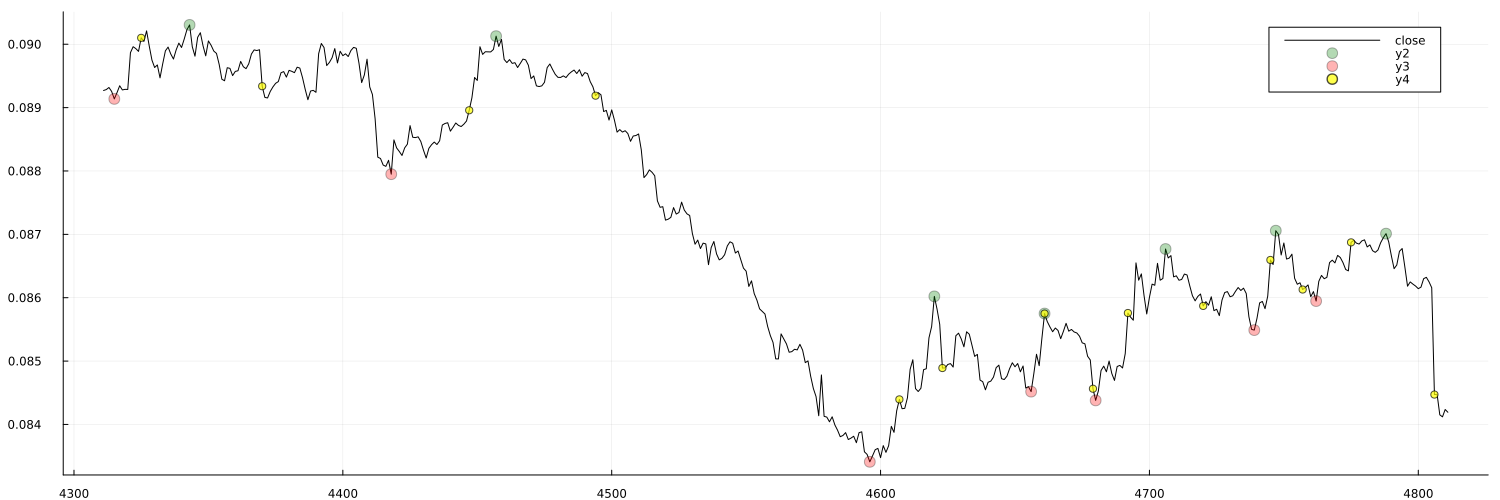

In [127]:
# lclose = 
# xclose = exp.(log.(odf.close))
# eps = 0.3*(std(lclose))
eps = 0.01
xtr = xtremas(xclose, eps)
idxups = findall(x->x>0, xtr[2,:])
idxdns = findall(x->x<0, xtr[2,:])
ixups = xtr[1, idxups]
ixdns = xtr[1, idxdns]
ixtrns = xtr[3,:]
####################
s = lclose
# s = odf.close
# s = exp.(-log.(odf.close))
# ws,we = 400,800
ws,we = nrow(odf)-500,nrow(odf)

wdf = odf[ws:we,:]
# wtarr = TimeArray(wdf,timestamp=:time)
# wtarr = TimeArray(wdf,timestamp=:time)
# wts = timestamp(wtarr)
# wdft = dft[(dft.iEnter .>= ws) .&& (dft.iExit .<= we),:] 

# iwEnter = [x for x in dft.iEnter if x in ws:we]
# iwExit = [x for x in dft.iExit if x in ws:we]
iwxups = [x for x in ixups if x in ws:we]
iwxdns = [x for x in ixdns if x in ws:we]
iwxtrns = [x for x in ixtrns if x in ws:we]
# plot(wtarr,size=(1500,500),st=:candlestick, xticks = 5, xrotation = 60)
plot(ws:we,wdf.lclose,size=(1500,500);label="close", linewidth=1, linecolor=:black)
scatter!(iwxups, s[iwxups], marker=(:circle,6,:green,:green), alpha=0.3)
scatter!(iwxdns, s[iwxdns], marker=(:circle,6,:red,:red), alpha=0.3)
scatter!(iwxtrns, s[iwxtrns], marker=(:circle,4,:yellow,:yellow), alpha=0.7)
# plot!(ws:we,ichi[ws:we,1];label="tenkan", linecolor=:blue)
# plot!(ws:we,ichi[ws:we,2];label="kijun", linecolor=:red)
# plot!(ws:we,ichi[ws:we,3], fillrange = ichi[ws:we,4], fillalpha = 0.35, fillcolor=:gray)
# plot!(twinx(),vcat([0],iwExit), vcat([0],dft.cpnl), linewidth=3, linecolor=:orange)
# plot!(twinx(),vcat(ws-1,wdft.iExit), vcat([0],cumsum(wdft.pnl)), linewidth=3, linecolor=:orange)
# vline!(wdft.iEnter, alpha=0.3)
# vline!(wdft.iExit, linecolor=:red, alpha=0.3)
# plot!(ichi[ws:we,3:4], fillcolor = plot_color(:yellow, 0.3))

In [28]:
# maximum(wdf.close) / minimum(wdf.close) - 1
maximum(lclose) / minimum(lclose) - 1
# wdf.close.min()

0.8565856836078054

In [ ]:
Heuristic Diversification- Equal Weighting and Risk Parity